In [1]:
import pandas as pd
import numpy as np
import os
import cstarpy.inference
import cstarpy.integration
from cstarpy.preprocessing import PerturbationMagnitude
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
import matplotlib.pyplot as plt
import openpyxl

In [2]:
# R_global_annotated = R_global_core.csv  (modules × drugs)
# R_global_DPDonly = DPD response row    (DPD × drugs)
# pert_modules = pert_matrix.csv     (modules × drugs)
# forbidden_connections = built in-code (no Excel sheet)

CD8_DIR = "02_outputs"


R_global_core_df = pd.read_csv("/Users/samuelnugent/Desktop/Masters/Spring/MEIN40430/Thesis/New Results/scripts/02_outputs/R_global_core_top4_bottom4.csv", index_col=0)
R_global_DPD_df = pd.read_csv("/Users/samuelnugent/Desktop/Masters/Spring/MEIN40430/Thesis/New Results/scripts/02_outputs/R_global_DPDonly_top4_bottom4.csv", index_col=0)

modules_core = R_global_core_df.index.tolist()
modules_DPD = R_global_DPD_df.index.tolist()

exp_ids = R_global_core_df.columns.tolist()

#R_global = R_global_df.values
#n_modules = R_global.shape[0]

#print(R_global.shape)
#display(R_global_df)
pert_modules_df = pd.read_csv("02_outputs/pert_matrix_top4_bottom4.csv", index_col=0)

In [3]:
out_dir = "02_outputs"

G_not_df = pd.DataFrame(False, index=modules_core, columns=modules_core)
np.fill_diagonal(G_not_df.values, True)
r_mean_br = cstarpy.inference.run_mra(
            R_global_core_df.values,
            pert_modules_df.values,
            G_not=G_not_df.values,
            method='br',
            pvalue_threshold=0.05)

r_mean_br_df = pd.DataFrame(r_mean_br, index = modules_core, columns = modules_core)
np.fill_diagonal(r_mean_br_df.values, -1) 
r_mean_br_df

100%|██████████| 7/7 [00:00<00:00, 107.27it/s]


,ARFGAP,BCL,IGF1R,JAK,MTOR,NAE,SERCA
ARFGAP,-1.000000,0.0,0.00000,0.000000,0.00000,0.0,0.000000
BCL,0.000000,-1.0,0.00000,0.000000,0.00000,0.0,0.231518
IGF1R,0.000000,0.0,-1.00000,0.002194,0.00000,0.0,0.000000
JAK,0.000000,0.0,0.85923,-1.000000,0.54081,0.0,0.000000
MTOR,0.000000,0.0,0.00000,0.001707,-1.00000,0.0,0.000000
NAE,0.367413,0.0,0.00000,0.000000,0.00000,-1.0,0.906151
SERCA,0.000000,0.0,0.00000,0.000000,0.00000,0.0,-1.000000


In [4]:
rp = PerturbationMagnitude(R=R_global_core_df, pert=pert_modules_df, r=r_mean_br_df)
rp.estimate(alpha=1.0)

n_iter = 1200

rps_diff, r_mean, rp_final= cstarpy.inference.run_mra_rp(
            R_global_core_df,
            pert_modules_df,
            G_not=G_not_df.values,
            method='br',
            pvalue_threshold=0.05,
            alpha=10.0,
            rp_init=rp,
            rp_relax=0.005,
            show_progress_bar=True,
            n_iter=n_iter)

r_mean_df = pd.DataFrame(r_mean, index = modules_core, columns = modules_core)
np.fill_diagonal(r_mean_df.values, -1) 

100%|██████████| 1200/1200 [00:19<00:00, 60.39it/s]


In [5]:
r_mean_df = pd.DataFrame(r_mean, index = modules_core, columns = modules_core)
np.fill_diagonal(r_mean_df.values, -1) 

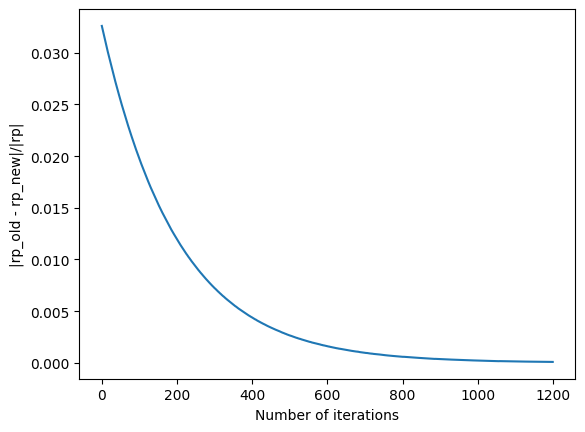

In [6]:
import pylab as plt
plt.plot(np.arange(n_iter),rps_diff)
plt.xlabel('Number of iterations')
plt.ylabel('|rp_old - rp_new|/|rp|')
plt.show()

In [7]:
rps_diff[-1]/np.linalg.norm(rp.df,ord='fro')
print(np.min(rps_diff/np.linalg.norm(rp.df,ord='fro')))
print(np.argmin(rps_diff/np.linalg.norm(rp.df,ord='fro')))

1.4938641490644612e-05
1199


In [8]:
COMPOUND_FILE = "cd8_limma_merged_filtered_targets_ic50_dpd.csv"

df = pd.read_csv(COMPOUND_FILE)
df_avg = (
    df.groupby(["compound_name", "gene"])
    .agg(logFC=("logFC", "mean"), adj_P_Val=("adj.P.Val", "mean"))
    .reset_index()
)
df_avg["logFC_thresh"] = np.where(df_avg["adj_P_Val"] < 0.05, df_avg["logFC"], 0)

pivot = df_avg.pivot_table(index="compound_name", columns="gene",
                            values="logFC_thresh", aggfunc="first").fillna(0)

BTLA_REF_FILE = "/Users/samuelnugent/Desktop/Masters/Spring/MEIN40430/Thesis/New Results/data/BTLAvsTCR_24h.csv"
BTLA_REF_COL  = "stat"

btla_ref = pd.read_csv(BTLA_REF_FILE)
btla_ref["gene"] = btla_ref["gene"].astype(str).str.strip()
btla_ref = btla_ref.set_index("gene")

common_genes_btla   = pivot.columns.intersection(btla_ref.index)
pivot_aligned_btla  = pivot[common_genes_btla]
btla_ref_aligned    = btla_ref.loc[common_genes_btla, BTLA_REF_COL].values

STV_btla = btla_ref_aligned / np.linalg.norm(btla_ref_aligned)

btla_dpd_vec = pivot_aligned_btla.values @ STV_btla

btla_df = pd.DataFrame({
    "compound_name" : pivot_aligned_btla.index,
    "btla_dpd"      : btla_dpd_vec.round(4),
}).sort_values("btla_dpd", ascending=False).reset_index(drop=True)

btla_df.to_csv("btla_deg_per_compound_btla.csv", index=False)
print("\n✓ Saved btla_deg_per_compound_btla.csv")




✓ Saved btla_deg_per_compound_btla.csv


In [9]:
dpd_by_drug = (
    pd.read_csv("02_outputs/R_global_DPDonly_top4_bottom4.csv", index_col=0)
    .loc["DPD"]
)

btla_by_drug = (
    pd.read_csv("btla_deg_per_compound_btla.csv")
    .set_index("compound_name")["btla_dpd"]
)

R_global_core_df = R_global_core_df.reindex(columns=exp_ids)
pert_modules_df  = pert_modules_df.reindex(columns=exp_ids)
R_global_DPD_df  = pd.DataFrame([dpd_by_drug.reindex(exp_ids)], index=["DPD"])
R_global_BTLA_df = pd.DataFrame([btla_by_drug.reindex(exp_ids)], index=["BTLA"])
R_global_fptu_df = pd.concat([R_global_DPD_df, R_global_BTLA_df])

G_not_fptu = pd.DataFrame(False, index=R_global_fptu_df.index, columns=R_global_core_df.index)

r_fptu = cstarpy.inference.run_regularized_mra_fptu(
    data_perturbed=R_global_core_df,
    data_unperturbed=R_global_fptu_df,
    pert=pert_modules_df.values,
    G_not=G_not_fptu.values,
    method='br',
    threshold=0.1,
    pvalue_threshold=0.4,
    progress_bar='off')

r_fptu_df = pd.DataFrame(r_fptu, index=["DPD", "BTLA"], columns=modules_core)
print("Modules → DPD:")
print(r_fptu_df.loc["DPD"].sort_values().round(3).to_string())
print("\nModules → BTLA:")
print(r_fptu_df.loc["BTLA"].sort_values().round(3).to_string())


Modules → DPD:
SERCA    -5.071
NAE      -4.078
ARFGAP    0.000
BCL       0.000
IGF1R     0.000
MTOR      3.274
JAK       6.069

Modules → BTLA:
ARFGAP    0.0
BCL       0.0
IGF1R     0.0
JAK       0.0
MTOR      0.0
NAE       0.0
SERCA     0.0


In [10]:
nodes = modules_core + ["DPD", "BTLA"]
r_total_mean = pd.DataFrame(np.zeros((len(nodes), len(nodes))), index=nodes, columns=nodes)
r_total_mean.loc[modules_core, modules_core] = r_mean
r_total_mean.loc["DPD", modules_core] = r_fptu_df.loc["DPD", modules_core].values
r_total_mean.loc["BTLA", modules_core] = r_fptu_df.loc["BTLA", modules_core].values
np.fill_diagonal(r_total_mean.values, -1)
r_total_mean.to_csv(os.path.join(out_dir, "r_mean_ols_rp_fptu_prefinal_btla.csv"))
rm_minus_inv = pd.DataFrame(np.linalg.pinv(r_total_mean.values), index=nodes, columns=nodes) * (-1)
rm_minus_inv.to_csv(os.path.join(out_dir, "r_minv_ols_rp_fptu_prefinal_btla.csv"))

In [11]:
print("Connection matrix r (modules + DPD):")
print(r_total_mean.round(3).to_string())

print("\nMinus inverse −r⁻¹ (modules + DPD):")
print(rm_minus_inv.round(3).to_string())


Connection matrix r (modules + DPD):
        ARFGAP  BCL  IGF1R    JAK   MTOR    NAE  SERCA  DPD  BTLA
ARFGAP  -1.000  0.0  0.000  0.000  0.000  0.000  0.000  0.0   0.0
BCL      0.000 -1.0  0.000  0.000  0.000  0.000  0.282  0.0   0.0
IGF1R    0.000  0.0 -1.000  0.000  0.000  0.000  0.000  0.0   0.0
JAK      0.000  0.0  1.113 -1.000  0.582  0.000  0.000  0.0   0.0
MTOR     0.000  0.0  0.000  0.000 -1.000  0.000  0.000  0.0   0.0
NAE      0.378  0.0  0.000  0.000  0.000 -1.000  0.860  0.0   0.0
SERCA    0.000  0.0  0.000  0.000  0.000  0.000 -1.000  0.0   0.0
DPD      0.000  0.0  0.000  6.069  3.274 -4.078 -5.071 -1.0   0.0
BTLA     0.000  0.0  0.000  0.000  0.000  0.000  0.000  0.0  -1.0

Minus inverse −r⁻¹ (modules + DPD):
        ARFGAP  BCL  IGF1R    JAK   MTOR    NAE  SERCA  DPD  BTLA
ARFGAP   1.000  0.0  0.000 -0.000 -0.000  0.000 -0.000 -0.0  -0.0
BCL      0.000  1.0  0.000  0.000  0.000 -0.000  0.282  0.0  -0.0
IGF1R   -0.000  0.0  1.000  0.000  0.000 -0.000 -0.000 -0.0  -0.0
JA

In [12]:
R_with_dpd = pd.concat([R_global_core_df, R_global_DPD_df])
pert_full  = pert_modules_df.reindex(index=nodes, fill_value=0)   # add DPD row = 0

r_I = R_with_dpd.reindex(index=nodes).fillna(0) * pert_full

R_I_pred = pd.DataFrame(
    rm_minus_inv.values @ r_I.values,
    index=nodes, columns=exp_ids,
)
print("Predicted systems-level response R_I = -r⁻¹ · r_I:")
print(R_I_pred.round(3).to_string())

# Validate: does the network-based prediction match the directly measured response?
observed = R_with_dpd.reindex(index=nodes)
corr = pd.Series(R_I_pred.values.flatten()).corr(pd.Series(observed.values.flatten()))
print(f"\nCorrelation between predicted R_I and observed R: {corr:.3f}")



Predicted systems-level response R_I = -r⁻¹ · r_I:
        QS-11  navitoclax  BMS-536924  AT9283  TG-101348  CYT-387  ruxolitinib  Deforolimus  Temsirolimus  Sapanisertib  Pevonedistat  Thapsigargin
ARFGAP -1.252      -0.000      -0.000   0.000      0.000    0.000        0.000        0.000         0.000         0.000        -0.000         0.000
BCL    -0.000      -1.596      -0.000  -0.000     -0.000   -0.000       -0.000       -0.000        -0.000        -0.000         0.000        -0.498
IGF1R   0.000      -0.000      -1.434  -0.000     -0.000   -0.000       -0.000       -0.000        -0.000        -0.000         0.000         0.000
JAK     0.000       0.000      -1.596  -1.146     -1.530   -1.347       -1.925       -0.949        -1.116        -1.147         0.000         0.000
MTOR    0.000       0.000      -0.000  -0.000     -0.000   -0.000       -0.000       -1.631        -1.918        -1.972         0.000         0.000
NAE    -0.473       0.000      -0.000   0.000      0.000    0

In [13]:
r_OLS = r_total_mean
r_OLS
# input for CytoScape
con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in r_OLS.index:
    for con_from in r_OLS.columns:
        if ((r_OLS.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,r_OLS.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv('CD8_r_net_br.txt',sep='\t',index=False)
